# CCA integration: gex-only, morph-only, joint

Trying a simpler model than scvi and DIABLO

- **PCA (gex only)** — transcriptomic profile per drug
- **PCA (morph only)** — Cell Painting morphology profile per drug
- **CCA (joint)** — both modalities integrated together

[Canonical Correlation Analysis](https://scikit-learn.org/stable/modules/cross_decomposition.html#canonical-correlation-analysis)
finds paired linear projections of two views of the same objects that
maximize the correlation between the projected scores — the direct linear
analogue of what totalVI does non-linearly.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import mudata as md
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

SEED = 0
np.random.seed(SEED)

N_LATENT = 20     # single-modality PCA embedding dim -- matches wl_integration_scvi.ipynb
N_PCS = 15        # per-modality PCA compression fed into CCA (see note below)
N_LATENT_CCA = 10 # joint CCA embedding dim -- deliberately smaller than N_LATENT, see note below

## Load data

columns changed form string to category to avoid scanpy plotting errors

In [16]:
mdata = md.read_h5mu("data/hepg2_mdata.h5mu")
gex = mdata["gex"]
morph = mdata["morph"]

for col in mdata.obs.columns:
    if str(mdata.obs[col].dtype) == "string":
        mdata.obs[col] = mdata.obs[col].astype(str).astype("category")

mdata

MuData object with n_obs × n_vars = 119 × 42416
  obs:	'drug', 'cell_line_id', 'n_cells', 'moa-fine', 'canonical_smiles', 'pubchem_cid'
  2 modalities
    morph:	119 × 636
      obs:	'drug', 'cell_line_id', 'n_cells', 'moa-fine', 'canonical_smiles', 'pubchem_cid'
      layers:	None
    gex:	119 × 41780
      obs:	'drug', 'cell_line_id', 'n_cells', 'moa-fine', 'canonical_smiles', 'pubchem_cid'
      layers:	'log_counts', 'raw_counts', None

Make plots colour-comparable across notebooks.

In [17]:
moa_fine_colors = pd.read_csv("data/mixOmics/moa_fine_colors.csv").set_index("moa_fine")["color"]
mdata.uns["moa-fine_colors"] = moa_fine_colors.loc[mdata.obs["moa-fine"].cat.categories].to_numpy()

## Preprocessing

PCA and CCA are both linear methods on continuous data, so unlike scVI/totalVI
there's no need for raw counts or a non-negative morphology layer here:

- **gex**: reuse the same top-5,000 `seurat_v3` HVG selection as the scVI
  notebook (fit on raw counts, as `seurat_v3` requires), but take the
  `log_counts` layer of those HVGs, z-scored per gene, as the continuous
  input to PCA/CCA.
- **morph**: `morph.X` is already the MAD-robustized, per-feature z-scored
  Cell Painting profile used elsewhere in this repo -- ready to use as-is.

In [18]:
sc.pp.highly_variable_genes(gex, flavor="seurat_v3", n_top_genes=5000, layer="raw_counts")

gex_hvg = gex[:, gex.var["highly_variable"]].copy()
print(f"{gex_hvg.n_vars} / {gex.n_vars} genes kept as HVGs")

X_gex = StandardScaler().fit_transform(np.asarray(gex_hvg.layers["log_counts"].todense())
                                        if hasattr(gex_hvg.layers["log_counts"], "todense")
                                        else gex_hvg.layers["log_counts"])
X_morph = np.asarray(morph.X)

5000 / 41780 genes kept as HVGs


## 1) PCA — gex only

`N_PCS=15` components are kept per modality as the compressed input to CCA
(see below); the single-modality baseline embeddings used for UMAP/metrics
here instead take `N_LATENT=20` PCA components directly, to stay
dimension-matched with the scVI/totalVI embeddings.

In [19]:
# fit once at N_LATENT components; the leading N_PCS columns of a PCA fit
# are identical regardless of how many total components were requested, so
# this one fit serves both the N_LATENT-dim baseline and the N_PCS-dim CCA input
gex_pca = PCA(n_components=N_LATENT, random_state=SEED)
gex_pcs = gex_pca.fit_transform(X_gex)

mdata.obsm["X_pca_gex"] = gex_pcs
print(f"{gex_pca.explained_variance_ratio_.sum():.1%} of variance in top {N_LATENT} gex PCs")
mdata.obsm["X_pca_gex"].shape

60.2% of variance in top 20 gex PCs


(119, 20)

## 2) PCA — morph only

In [20]:
morph_pca = PCA(n_components=N_LATENT, random_state=SEED)
morph_pcs = morph_pca.fit_transform(X_morph)

mdata.obsm["X_pca_morph"] = morph_pcs
print(f"{morph_pca.explained_variance_ratio_.sum():.1%} of variance in top {N_LATENT} morph PCs")
mdata.obsm["X_pca_morph"].shape

98.1% of variance in top 20 morph PCs


(119, 20)

## 3) CCA — joint gex + morph

CCA is fit on the top `N_PCS=15` PCA scores of each view (not the raw
5,000/636-feature matrices, and fewer than the `N_LATENT=20` used for the
single-modality baselines above) -- with only 119 drugs, both of those
larger feature counts put CCA in `n_features > n_samples` territory, where
it can find "perfect" but meaningless canonical correlations (confirmed by
the held-out diagnostic below: an initial `N_PCS=30, N_LATENT_CCA=20`
attempt had in-sample correlations of ~0.7 collapse to ~0.15 out of
sample). Compressing each view first, *and* asking CCA for fewer canonical
components (`N_LATENT_CCA=10`) than the single-modality PCA baselines use,
is the standard fix -- the linear-method equivalent of scVI/totalVI needing
HVG selection for the same reason.

`CCA.fit_transform` returns a pair of score matrices, `gex_c` and
`morph_c` (one per view, both `119 x N_LATENT_CCA`), aligned so that
column `i` of each is the `i`-th canonical variate pair -- maximally
correlated with each other, decreasingly so down the columns. The **joint
embedding** is their element-wise mean: same shared axes, denoised of each
view's private noise.

In [22]:
cca = CCA(n_components=N_LATENT_CCA, max_iter=5000)
gex_c, morph_c = cca.fit_transform(gex_pcs[:, :N_PCS], morph_pcs[:, :N_PCS])

canonical_corrs = np.array([
    np.corrcoef(gex_c[:, i], morph_c[:, i])[0, 1] for i in range(N_LATENT_CCA)
])
print("per-component canonical correlations (full data, in-sample):")
print(np.round(canonical_corrs, 3))

mdata.obsm["X_cca_joint"] = (gex_c + morph_c) / 2
mdata.obsm["X_cca_joint"].shape

per-component canonical correlations (full data, in-sample):
[0.901 0.854 0.801 0.633 0.569 0.427 0.352 0.338 0.229 0.196]


(119, 10)

### Embeddings

Export the embeddings for each method for benchmarking

In [25]:
for emb in ["X_pca_morph", "X_pca_gex", "X_cca_joint"]:
    embedding_df = pd.DataFrame(
        mdata.obsm[emb],
        index=mdata.obs["drug"].astype(str),
        columns=[f"{emb}_{i + 1}" for i in range(mdata.obsm[emb].shape[1])],
    )
    embedding_df.index.name = "drug"
    embedding_df.to_csv(f"data/CCA/{emb}.csv")

### Diagnostic: is the canonical correlation real, or just overfitting?

In-sample canonical correlations on a linear model fit with few samples
relative to its dimensionality are inflated almost by construction, so
they're not trustworthy on their own. As a check (mirroring the 90/10
`train_size` split scVI/totalVI use for early stopping), refit CCA on a
90% training split and correlate its projections on the held-out 10% --
correlations that survive on unseen drugs indicate real shared structure
rather than the model memorizing 119 points in a handful of dimensions.
With only ~12 held-out drugs this diagnostic is itself quite noisy (same
caveat as the validation-ELBO note in the scVI notebook) -- small enough
that it's better read as "does the correlation collapse toward zero"
than as a precise number. This diagnostic doesn't feed into any embedding
used below -- `X_cca_joint` above is always the full-data fit.

In [8]:
train_idx, val_idx = train_test_split(np.arange(mdata.n_obs), train_size=0.9, random_state=SEED)

cca_cv = CCA(n_components=N_LATENT_CCA, max_iter=5000)
cca_cv.fit(gex_pcs[train_idx, :N_PCS], morph_pcs[train_idx, :N_PCS])
gex_val_c, morph_val_c = cca_cv.transform(gex_pcs[val_idx, :N_PCS], morph_pcs[val_idx, :N_PCS])

val_corrs = np.array([
    np.corrcoef(gex_val_c[:, i], morph_val_c[:, i])[0, 1] for i in range(N_LATENT_CCA)
])
print(f"held-out canonical correlations ({len(val_idx)} drugs):")
print(np.round(val_corrs, 3))
print(f"mean over all {N_LATENT_CCA} components: {val_corrs.mean():.3f} (in-sample mean: {canonical_corrs.mean():.3f})")

held-out canonical correlations (12 drugs):
[-0.061 -0.014  0.184 -0.427  0.523 -0.366 -0.105  0.116  0.083 -0.08 ]
mean over all 10 components: -0.015 (in-sample mean: 0.530)


In [9]:
# sanity check: none of the three latents came out with NaNs
for name, key in [("gex", "X_pca_gex"), ("morph", "X_pca_morph"), ("joint", "X_cca_joint")]:
    lat = mdata.obsm[key]
    assert not np.isnan(lat).any(), f"{name} embedding contains NaNs"
print("all three embeddings are NaN-free")

all three embeddings are NaN-free


## UMAP

Compare the integration quality to cluster MoA together

In [10]:
embedding_keys = {
    "PCA (gex only)": "X_pca_gex",
    "PCA (morph only)": "X_pca_morph",
    "CCA (joint)": "X_cca_joint",
}
n_methods = len(embedding_keys)

for key in embedding_keys.values():
    sc.pp.neighbors(mdata, use_rep=key, metric="cosine", key_added=key)
    sc.tl.umap(mdata, neighbors_key=key, key_added=f"{key}_umap")

## Compare embeddings by `drug` and `moa-fine`

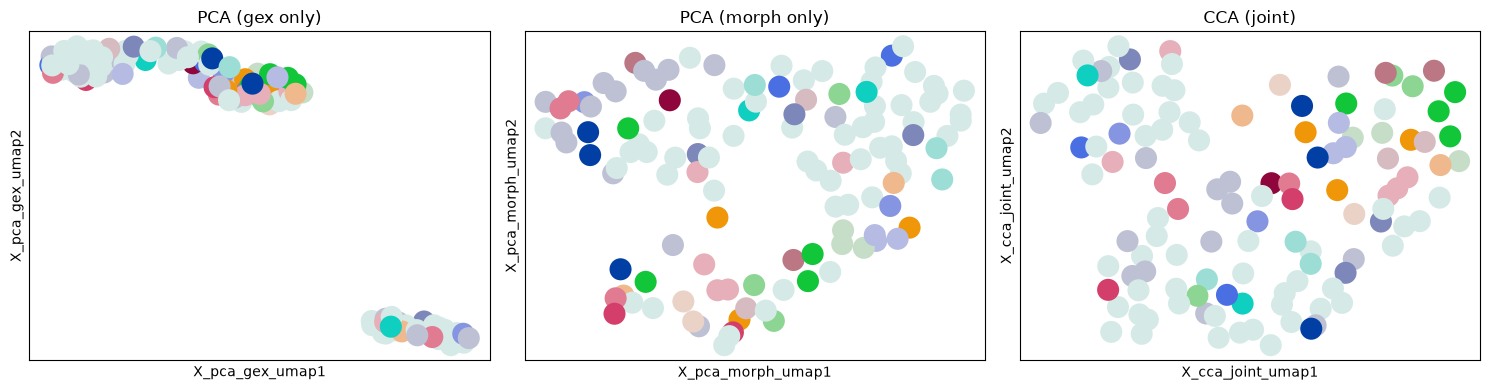

In [11]:
fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 4), squeeze=False)

for ax, (method_name, key) in zip(axes.ravel(), embedding_keys.items()):
    sc.pl.embedding(
        mdata,
        basis=f"{key}_umap",
        color="moa-fine",
        ax=ax,
        show=False,
        title=method_name,
        legend_loc=None,
        legend_fontsize=8,
    )

fig.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.savefig("figures/umap_comparison_cca.png", dpi=300)
plt.show()


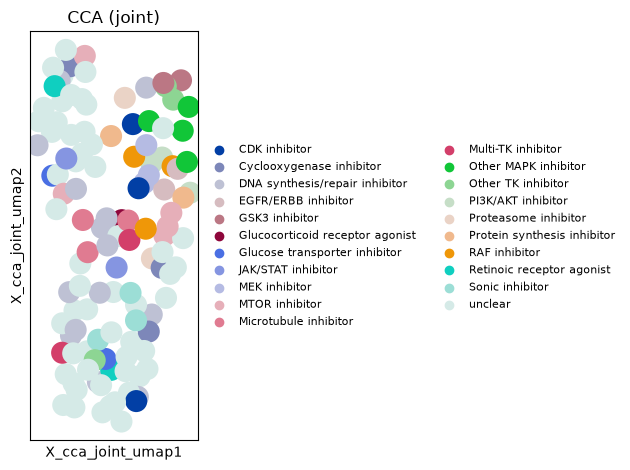

In [12]:
sc.pl.embedding(
    mdata,
    basis="X_cca_joint_umap",
    color="moa-fine",
    show=False,
    title="CCA (joint)",
    legend_loc="right margin",
    legend_fontsize=8,
)
plt.tight_layout()
plt.savefig("figures/umap_cca_joint.png", dpi=300)

## Integration metrics: how well does each embedding recapitulate drug structure?

Same protocol as `wl_integration_scvi.ipynb`: `moa-fine` as the reference
grouping, 55/119 `"unclear"` drugs excluded from all label-based metrics
below (64 drugs across 20 MOA categories remain).

- **Silhouette score** (`moa-fine` labels, embedding coordinates)
- **kNN purity (k=5)**
- **Enrichment over chance** (kNN purity / chance-level purity)
- **ARI / NMI** (K-means, k = number of MOA categories, vs. true labels)

In [14]:
known = mdata.obs["moa-fine"] != "unclear"
labels_all = mdata.obs["moa-fine"].astype(str).to_numpy(dtype=object)
print(f"{known.sum()} / {mdata.n_obs} drugs have a known moa-fine label")


def knn_purity(X, labels, k=5):
    """Fraction of each point's k nearest neighbors sharing its label."""
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X)
    _, idx = nn.kneighbors(X)
    idx = idx[:, 1:]  # drop self
    return (labels[idx] == labels[:, None]).mean(axis=1)


rows = []
for name, key in embedding_keys.items():
    Xk = mdata.obsm[key][known.values]
    lk = labels_all[known.values]

    silhouette = silhouette_score(Xk, lk, metric="euclidean")

    purity_k5 = knn_purity(Xk, lk, k=5).mean()
    group_size = pd.Series(lk).map(pd.Series(lk).value_counts()).to_numpy()
    chance_k5 = ((group_size - 1) / (len(lk) - 1)).mean()

    kmeans = KMeans(n_clusters=pd.Series(lk).nunique(), n_init=10, random_state=0).fit(Xk)
    ari = adjusted_rand_score(lk, kmeans.labels_)
    nmi = normalized_mutual_info_score(lk, kmeans.labels_)

    rows.append(dict(
        embedding=name,
        silhouette_moa=silhouette,
        knn_purity_k5=purity_k5,
        chance_k5=chance_k5,
        enrichment_k5=purity_k5 / chance_k5,
        ari_kmeans=ari,
        nmi_kmeans=nmi,
    ))

metrics_df = pd.DataFrame(rows).set_index("embedding").round(3)
metrics_df.to_csv("figures/cca_metrics.csv")
metrics_df

64 / 119 drugs have a known moa-fine label


,silhouette_moa,knn_purity_k5,chance_k5,enrichment_k5,ari_kmeans,nmi_kmeans
embedding,,,,,,
PCA (gex only),-0.322,0.141,0.069,2.040,0.058,0.576
PCA (morph only),-0.270,0.181,0.069,2.629,0.104,0.628
CCA (joint),-0.233,0.156,0.069,2.266,0.093,0.601


Read the table as: **higher is better** on every column, same as the
scVI notebook. If `CCA (joint)` beats both single-modality PCA rows on
`enrichment_k5` (and/or `ari_kmeans` / `nmi_kmeans`), the shared canonical
axes are picking up cross-modal MOA structure neither modality carries
alone; if it lands between the two single-modality rows, it's likely just
following whichever modality has the stronger MOA signal on its own.